#SELECCIÓN DE JUGADORES CON MÉTODOS DE CRISP-DM
##Búsqueda urgente de un sustituto de Tubault Courtois en la portería del REal Madrid. Para ello vamos a utilizar diferentes modelos de clasificación de SKLEarn y evaluaremos cual es el más apropiado:

###Decision tree
###Random Forest
###SVM
###KNeignorsClassifier



##1. Carga de Datos

###El primer paso es instaurar la api de la cual vamos a sacar los datos avanzados de los porteros.

In [22]:
import requests
import json

# Configuración de la API
api_key = "429e6d572f0a4fbcf595cb53daebee83"
url = "https://v3.football.api-sports.io/players"

headers = {
    'x-rapidapi-host': 'v3.football.api-sports.io',
    'x-rapidapi-key': api_key
}



Para cargar los datos desde la API vamos a escoger el puesto de portero, las métricas avanzadas que queremos comparar y las temporadas de las que queremos sacar los datos (2025 y 2026). Además es importante que al tratar dos temporadas unifiquemos los datos de los jugadores, para que no aparezcan dos iguales (uno por temporada)

In [49]:
import time
import pandas as pd
import numpy as np

# IDs de las ligas solicitadas
leagues = [140, 39, 135, 61, 78, 128, 71, 94, 88]
seasons = [2025, 2026]
raw_data = []

print(f"Iniciando extracción para {len(leagues)} ligas y temporadas {seasons}...")

for season in seasons:
    print(f"--- Procesando Temporada: {season} ---")
    for league_id in leagues:
        page = 1
        while True:
            params = {'league': str(league_id), 'season': str(season), 'page': str(page)}
            response = requests.get(url, headers=headers, params=params)
            if response.status_code != 200: break

            data_resp = response.json()
            players = data_resp.get('response', [])
            if not players: break

            for p in players:
                for stats in p['statistics']:
                    if stats['games']['position'] == 'Goalkeeper' and (stats['games']['minutes'] or 0) > 0:
                        raw_data.append({
                            'Player': p['player']['name'],
                            'Team': stats['team']['name'],
                            'Age': p['player']['age'],
                            'Appearances': stats['games']['appearences'] or 0,
                            'Minutes': stats['games']['minutes'] or 0,
                            'Passes': stats['passes']['total'] or 0,
                            'Pass_Acc': stats['passes']['accuracy'] or 0,
                            'Saves': stats['goals']['saves'] or 0,
                            'Conceded': stats['goals']['conceded'] or 0,
                            'Duels_Won': stats['duels']['won'] or 0
                        })
            if page >= data_resp.get('paging', {}).get('total', 1): break
            page += 1
            time.sleep(0.4)

# Agregamos los datos por jugador y equipo
df_raw = pd.DataFrame(raw_data)
agg_funcs = {
    'Age': 'max',
    'Appearances': 'sum',
    'Minutes': 'sum',
    'Passes': 'sum',
    'Pass_Acc': 'mean',
    'Saves': 'sum',
    'Conceded': 'sum',
    'Duels_Won': 'sum'
}
df_porteros_agg = df_raw.groupby(['Player', 'Team']).agg(agg_funcs).reset_index()

# Recalculamos métricas avanzadas sobre los totales
p90 = df_porteros_agg['Minutes'] / 90
total_shots = df_porteros_agg['Saves'] + df_porteros_agg['Conceded']

df_porteros = pd.DataFrame({
    'Player': df_porteros_agg['Player'],
    'Team': df_porteros_agg['Team'],
    'Age': df_porteros_agg['Age'],
    'Matches played': df_porteros_agg['Appearances'],
    'Minutes': df_porteros_agg['Minutes'],
    'Passes per 90': df_porteros_agg['Passes'] / p90,
    'Accurate passes, %': df_porteros_agg['Pass_Acc'],
    'Conceded goals': df_porteros_agg['Conceded'],
    'Conceded goals per 90': df_porteros_agg['Conceded'] / p90,
    'Shots against': total_shots,
    'Shots against per 90': total_shots / p90,
    'Save rate, %': (df_porteros_agg['Saves'] / total_shots * 100).fillna(0),
    'Prevented goals per 90': ((df_porteros_agg['Saves'] * 0.2) - (df_porteros_agg['Conceded'] * 0.1)) / p90,
    'Aerial duels per 90': df_porteros_agg['Duels_Won'] / p90
})

print(f"\nProceso finalizado. Porteros únicos: {len(df_porteros)}")
display(df_porteros.head())

Iniciando extracción para 9 ligas y temporadas [2025, 2026]...
--- Procesando Temporada: 2025 ---
--- Procesando Temporada: 2026 ---

Proceso finalizado. Porteros únicos: 402


,Player,Team,Age,Matches played,Minutes,Passes per 90,"Accurate passes, %",Conceded goals,Conceded goals per 90,Shots against,Shots against per 90,"Save rate, %",Prevented goals per 90,Aerial duels per 90
0,A. Aguerre,Central Cordoba de Santiago,35,44,3961,21.017420,29.5,45,1.022469,171,3.885382,73.684211,0.470336,0.477152
1,A. Areola,West Ham,32,20,1800,27.050000,46.0,37,1.850000,114,5.700000,67.543860,0.585000,0.300000
2,A. Batalla,Rayo Vallecano,29,30,2700,36.133333,64.0,35,1.166667,117,3.900000,70.085470,0.430000,0.500000
3,A. Bayındır,Manchester United,27,6,540,29.500000,60.0,11,1.833333,24,4.000000,54.166667,0.250000,0.833333
4,A. Desábato,Platense,35,6,556,16.187050,0.0,12,1.942446,22,3.561151,45.454545,0.129496,0.323741


##2. Preparación y normalización de los datos
###Antes de empezar a probar algoritmos, vamos preparar y normalizar los datos

In [51]:
df_porteros_filtrados = df_porteros[(df_porteros['Matches played'] >= 20) & (df_porteros['Age'] < 30)].copy()
print(f'Porteros originales: {len(df_porteros)}')
print(f'Porteros tras filtrar (mín. 20 partidos y < 30 años): {len(df_porteros_filtrados)}')

try:
    courtois_index = df_porteros[df_porteros['Player'].str.contains('Courtois', case=False)].index[0]
    courtois_row = df_porteros.loc[courtois_index]
    print(f'Referencia externa guardada: {courtois_row["Player"]}')
except IndexError:
    print('Courtois no encontrado en los datos originales.')

# Añadimos a Courtois al set final aunque no cumpla los filtros (referencia para la comparación)
if courtois_row['Player'] not in df_porteros_filtrados['Player'].values:
    df_porteros_final = pd.concat([pd.DataFrame([courtois_row]), df_porteros_filtrados]).drop_duplicates().reset_index(drop=True)
else:
    df_porteros_final = df_porteros_filtrados.reset_index(drop=True)

df_porteros = df_porteros_final
display(df_porteros.head())

Porteros originales: 79
Porteros tras filtrar (mín. 20 partidos y < 30 años): 78
Referencia externa guardada: T. Courtois


,Player,Team,Age,Matches played,Minutes,Passes per 90,"Accurate passes, %",Conceded goals,Conceded goals per 90,Shots against,Shots against per 90,"Save rate, %",Prevented goals per 90,Aerial duels per 90
0,T. Courtois,Real Madrid,33,28,2520,29.964286,79.0,24,0.857143,82,2.928571,70.731707,0.328571,0.285714
1,A. Batalla,Rayo Vallecano,29,30,2700,36.133333,64.0,35,1.166667,117,3.900000,70.085470,0.430000,0.500000
2,A. Murić,Sassuolo,27,31,2790,29.000000,60.0,41,1.322581,158,5.096774,74.050633,0.622581,0.612903
3,A. Nübel,VfB Stuttgart,29,29,2610,36.689655,72.0,38,1.310345,126,4.344828,69.841270,0.475862,0.448276
4,A. Trubin,Benfica,24,27,2430,19.259259,75.0,17,0.629630,75,2.777778,77.333333,0.366667,0.333333


Ahora que hemos normalizado los datos, el siguiente paso es preparar el perfil de Courtois con estas mismas características normalizadas. A partir de este perfil, podremos calcular la similitud con el resto de los porteros.

In [52]:
from sklearn.preprocessing import StandardScaler

# Buscamos a Courtois en el nuevo DataFrame para tenerlo como referencia
try:
    courtois_index = df_porteros[df_porteros['Player'].str.contains('Courtois', case=False, na=False)].index[0]
    print(f"Referencia encontrada: {df_porteros.loc[courtois_index, 'Player']} ({df_porteros.loc[courtois_index, 'Team']})")
except IndexError:
    print("ADVERTENCIA: Courtois no aparece en los datos de 2023 (estuvo lesionado). Usaremos el portero con mejores estadísticas generales como base o puedes indicar otro nombre.")
    # Como fallback para que el código no rompa, tomamos el primer índice
    courtois_index = 0

# Definir las características de juego que SÍ tienen datos (evitamos xG si es todo 0)
features_for_comparison = [
    'Passes per 90', 'Accurate passes, %',
    'Conceded goals per 90', 'Shots against per 90',
    'Save rate, %', 'Prevented goals per 90'
]

# Crear un DataFrame con solo las características seleccionadas
df_features = df_porteros[features_for_comparison].copy()

# Inicializar el StandardScaler
scaler = StandardScaler()

# Normalizar las características
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=features_for_comparison, index=df_porteros.index)

# Imputar cualquier NaN remanente con 0 (media)
df_scaled.fillna(0, inplace=True)

# Extraer el perfil de referencia escalado
courtois_scaled_ref = df_scaled.loc[courtois_index]

print('Primeras 5 filas del DataFrame normalizado:')
display(df_scaled.head())

print('\nPerfil de referencia para la comparación:')
display(courtois_scaled_ref)

Referencia encontrada: T. Courtois (Real Madrid)
Primeras 5 filas del DataFrame normalizado:


,Passes per 90,"Accurate passes, %",Conceded goals per 90,Shots against per 90,"Save rate, %",Prevented goals per 90
0,-0.176124,1.001998,-1.128330,-1.573499,0.081252,-1.405846
1,0.714898,0.304162,-0.305918,-0.440676,-0.046262,-0.404957
2,-0.315400,0.118073,0.108349,0.954932,0.736134,1.495413
3,0.795250,0.676341,0.075838,0.078056,-0.094447,0.047606
4,-1.722296,0.815908,-1.732838,-1.749346,1.383868,-1.029925



Perfil de referencia para la comparación:


,0
Passes per 90,-0.176124
"Accurate passes, %",1.001998
Conceded goals per 90,-1.128330
Shots against per 90,-1.573499
"Save rate, %",0.081252
Prevented goals per 90,-1.405846


## 3. Cálculo de Similitud con K-Nearest Neighbors (KNN)

Ahora utilizaremos el algoritmo K-Nearest Neighbors (KNN) para identificar porteros similares. Este método es una forma diferente de medir la similitud, basándose en la distancia entre puntos de datos en un espacio de características.


In [54]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd

# Usamos el DataFrame escalado que ya contiene las métricas de la nueva API
df_knn = df_scaled[features_for_comparison].copy()

# Inicializar el modelo NearestNeighbors
k = 10
neigh = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
neigh.fit(df_knn)

# Preparamos la referencia de Courtois como un DataFrame para evitar el UserWarning de feature names
courtois_query = pd.DataFrame([courtois_scaled_ref[features_for_comparison]], columns=features_for_comparison)

# Encontrar los k+1 vecinos más cercanos
distances, indices = neigh.kneighbors(courtois_query)

# Obtener los índices excluyendo a Courtois (el primer resultado)
similar_indices = indices.flatten()[1:]

# Crear el DataFrame de resultados con los datos de la nueva API
df_knn_similar_goalkeepers = df_porteros.iloc[similar_indices].copy()
df_knn_similar_goalkeepers['distance_to_courtois'] = distances.flatten()[1:]

# Ordenar por similitud
df_knn_similar_goalkeepers = df_knn_similar_goalkeepers.sort_values(by='distance_to_courtois')

print(f'\nLos {k} porteros más similares a Courtois (Referencia: {df_porteros.loc[courtois_index, "Player"]}) utilizando KNN:')
display(df_knn_similar_goalkeepers[['Player', 'Team', 'Age', 'distance_to_courtois']])


Los 10 porteros más similares a Courtois (Referencia: T. Courtois) utilizando KNN:


,Player,Team,Age,distance_to_courtois
54,M. Di Gregorio,Juventus,28,0.978220
46,L. Horníček,SC Braga,23,0.991690
28,G. Donnarumma,Manchester City,26,1.058070
29,G. Kobel,Borussia Dortmund,28,1.314914
9,B. Özer,Lille,25,1.326062
65,R. Risser,Lens,21,1.386913
75,V. Milinković-Savić,Napoli,28,1.545877
50,Luíz Júnior,Villarreal,24,1.812814
15,D. Greif,Lyon,28,1.962133
32,Gabriel Batista,Santa Clara,27,1.986233


## 4. Cálculo de Similitud con Árbol de Decisión (Decision Tree)

Para aplicar un modelo de clasificación como el Árbol de Decisión, necesitamos definir una variable objetivo. En este caso, crearemos una etiqueta 'similar' o 'no similar' basada en la distancia euclidiana calculada previamente. Esto nos permitirá identificar qué características son importantes para clasificar a un portero como similar a Courtois.

In [55]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from scipy.spatial.distance import euclidean

# 1. Recalcular distancias y etiquetas de similitud con el nuevo set de datos
df_scaled['distance_to_courtois'] = df_scaled[features_for_comparison].apply(
    lambda row: euclidean(row, courtois_scaled_ref[features_for_comparison]), axis=1
)

# Definimos el percentil 25 como umbral para 'similar'
distance_threshold = df_scaled['distance_to_courtois'].quantile(0.25)
df_scaled['is_similar_to_courtois'] = (df_scaled['distance_to_courtois'] <= distance_threshold).astype(int)

# 2. Preparar datos para el modelo
X = df_scaled[features_for_comparison].copy()
y = df_scaled['is_similar_to_courtois'].copy()

# Excluir a Courtois del entrenamiento
X_train_dt_full = X.drop(index=courtois_index)
y_train_dt_full = y.drop(index=courtois_index)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_train_dt_full, y_train_dt_full, test_size=0.2, random_state=42, stratify=y_train_dt_full
)

# 3. Entrenar Árbol de Decisión
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_classifier.fit(X_train, y_train)

# 4. Evaluación
y_pred = dt_classifier.predict(X_test)
print('Rendimiento del Árbol de Decisión:')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

# 5. Predicción de sustitutos similares
all_predictions = dt_classifier.predict(X_train_dt_full)
similar_indices_dt = X_train_dt_full.index[all_predictions == 1]

df_dt_results = df_porteros.loc[similar_indices_dt].copy()
df_dt_results['distance_to_courtois'] = df_scaled.loc[similar_indices_dt, 'distance_to_courtois']

print(f'\nTop 10 porteros similares según Decision Tree (con filtro 20+ partidos):')
# Ajuste: Eliminamos 'Season' de la lista de visualización si no existe para evitar el KeyError
available_cols = [c for c in ['Player', 'Team', 'Season', 'distance_to_courtois'] if c in df_dt_results.columns]
display(df_dt_results.sort_values(by='distance_to_courtois')[available_cols].head(10))

Rendimiento del Árbol de Decisión:
Accuracy: 0.8750
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.75      0.75      0.75         4

    accuracy                           0.88        16
   macro avg       0.83      0.83      0.83        16
weighted avg       0.88      0.88      0.88        16


Top 10 porteros similares según Decision Tree (con filtro 20+ partidos):


,Player,Team,distance_to_courtois
54,M. Di Gregorio,Juventus,0.978220
46,L. Horníček,SC Braga,0.991690
28,G. Donnarumma,Manchester City,1.058070
29,G. Kobel,Borussia Dortmund,1.314914
9,B. Özer,Lille,1.326062
65,R. Risser,Lens,1.386913
75,V. Milinković-Savić,Napoli,1.545877
50,Luíz Júnior,Villarreal,1.812814
15,D. Greif,Lyon,1.962133
32,Gabriel Batista,Santa Clara,1.986233


## 5. Cálculo de Similitud con Random Forest

Continuando con los modelos de clasificación, ahora utilizaremos Random Forest. Este algoritmo es un conjunto de árboles de decisión que operan como un `ensemble`, corrigiendo el sobreajuste al que tienden los árboles individuales. Utilizaremos la misma variable objetivo (`is_similar_to_courtois`) definida para el Árbol de Decisión.

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Inicializar y entrenar el clasificador de Random Forest
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf = rf_classifier.predict(X_test)

print('\nRandom Forest Classifier Performance on Test Set:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred_rf))

# Predecir para todos los demás porteros (excluyendo a Courtois) para encontrar posibles sustitutos
# Usamos X_train_dt_full que es el set completo sin Courtois
all_predictions_rf = rf_classifier.predict(X_train_dt_full)

# Filtrar los jugadores predichos como 'similar' (clase 1)
rf_similar_indices = X_train_dt_full.index[all_predictions_rf == 1]

# Crear un DataFrame con los porteros similares identificados por Random Forest
df_rf_similar_goalkeepers = df_porteros.loc[rf_similar_indices].copy()

# Añadir la distancia a Courtois para contexto
df_rf_similar_goalkeepers['distance_to_courtois'] = df_scaled.loc[rf_similar_indices, 'distance_to_courtois']

# Ordenar por distancia a Courtois para presentar los más similares primero
df_rf_similar_goalkeepers = df_rf_similar_goalkeepers.sort_values(by='distance_to_courtois')

print(f'\nTop 10 porteros similares según Random Forest (con filtro 20+ partidos):')
available_cols_rf = [c for c in ['Player', 'Team', 'Season', 'distance_to_courtois'] if c in df_rf_similar_goalkeepers.columns]
display(df_rf_similar_goalkeepers[available_cols_rf].head(10))


Random Forest Classifier Performance on Test Set:
Accuracy: 0.8750
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.50      0.67         4

    accuracy                           0.88        16
   macro avg       0.93      0.75      0.79        16
weighted avg       0.89      0.88      0.86        16


Top 10 porteros similares según Random Forest (con filtro 20+ partidos):


,Player,Team,distance_to_courtois
54,M. Di Gregorio,Juventus,0.978220
46,L. Horníček,SC Braga,0.991690
28,G. Donnarumma,Manchester City,1.058070
29,G. Kobel,Borussia Dortmund,1.314914
9,B. Özer,Lille,1.326062
65,R. Risser,Lens,1.386913
75,V. Milinković-Savić,Napoli,1.545877
15,D. Greif,Lyon,1.962133
32,Gabriel Batista,Santa Clara,1.986233
18,Diogo Costa,FC Porto,1.992436


## 6. Cálculo de Similitud con Support Vector Machine (SVM)

Ahora incorporaremos el algoritmo Support Vector Machine (SVM) para identificar porteros similares. SVM busca el hiperplano que mejor separa las clases en un espacio dimensional elevado, lo que puede ser muy efectivo para la clasificación. Utilizaremos la misma variable objetivo (`is_similar_to_courtois`) que definimos anteriormente.

In [57]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Inicializar y entrenar el clasificador SVM
svc_classifier = SVC(random_state=42, probability=True)
svc_classifier.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_svc = svc_classifier.predict(X_test)

print('\nSupport Vector Machine Classifier Performance on Test Set:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred_svc))

# Predecir para todos los demás porteros (excluyendo a Courtois)
all_predictions_svc = svc_classifier.predict(X_train_dt_full)

# Filtrar los jugadores predichos como 'similar'
svc_similar_indices = X_train_dt_full.index[all_predictions_svc == 1]

# Crear un DataFrame con los resultados
df_svc_similar_goalkeepers = df_porteros.loc[svc_similar_indices].copy()
df_svc_similar_goalkeepers['distance_to_courtois'] = df_scaled.loc[svc_similar_indices, 'distance_to_courtois']

# Ordenar por distancia
df_svc_similar_goalkeepers = df_svc_similar_goalkeepers.sort_values(by='distance_to_courtois')

print(f'\nTop 10 porteros más similares a Courtois utilizando SVM (con filtro 20+ partidos):')
available_cols_svc = [c for c in ['Player', 'Team', 'Season', 'distance_to_courtois'] if c in df_svc_similar_goalkeepers.columns]
display(df_svc_similar_goalkeepers[available_cols_svc].head(10))


Support Vector Machine Classifier Performance on Test Set:
Accuracy: 0.9375
Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.75      0.86         4

    accuracy                           0.94        16
   macro avg       0.96      0.88      0.91        16
weighted avg       0.94      0.94      0.93        16


Top 10 porteros más similares a Courtois utilizando SVM (con filtro 20+ partidos):


,Player,Team,distance_to_courtois
54,M. Di Gregorio,Juventus,0.978220
46,L. Horníček,SC Braga,0.991690
28,G. Donnarumma,Manchester City,1.058070
29,G. Kobel,Borussia Dortmund,1.314914
9,B. Özer,Lille,1.326062
65,R. Risser,Lens,1.386913
75,V. Milinković-Savić,Napoli,1.545877
50,Luíz Júnior,Villarreal,1.812814
15,D. Greif,Lyon,1.962133
32,Gabriel Batista,Santa Clara,1.986233


#7. Aplicación de Grid Search

### Como podemos observar la valoración entre  Random Forest, SVM y KNeignorsClassifier es la misma y superior a decision tree. Esto nos hace descartar el modelo algorítmico del árbol de decisión

###Vemos que el nivel de eficacia de los modelos es bastante alto en todos, esto se debe al bajo número de datos en los que estamos entrenando a los algoritmos.

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Definir los rangos de parámetros para cada modelo
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'minkowski']
}

models = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'param_grid': param_grid_dt
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'param_grid': param_grid_rf
    },
    'SVM': {
        'model': SVC(random_state=42),
        'param_grid': param_grid_svc
    },
    'KNeighborsClassifier': {
        'model': KNeighborsClassifier(),
        'param_grid': param_grid_knn
    }
}

best_models = {}

print('--- Realizando Grid Search para cada modelo ---')

for name, config in models.items():
    print(f'\nEjecutando Grid Search para {name}...')
    grid_search = GridSearchCV(config['model'], config['param_grid'], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_

    print(f'Mejores parámetros para {name}: {grid_search.best_params_}')
    print(f'Mejor puntuación (accuracy) para {name}: {grid_search.best_score_:.4f}')

print('\n--- Comparativa de los mejores modelos en conjunto de prueba ---')

for name, model in best_models.items():
    test_accuracy = model.score(X_test, y_test)
    print(f'{name} - Precisión en el conjunto de prueba: {test_accuracy:.4f}')

--- Realizando Grid Search para cada modelo ---

Ejecutando Grid Search para Decision Tree...
Mejores parámetros para Decision Tree: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Mejor puntuación (accuracy) para Decision Tree: 0.8731

Ejecutando Grid Search para Random Forest...
Mejores parámetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejor puntuación (accuracy) para Random Forest: 0.8885

Ejecutando Grid Search para SVM...
Mejores parámetros para SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mejor puntuación (accuracy) para SVM: 0.8885

Ejecutando Grid Search para KNeighborsClassifier...
Mejores parámetros para KNeighborsClassifier: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Mejor puntuación (accuracy) para KNeighborsClassifier: 0.9205

--- Comparativa de los mejores modelos en conjunto de prueba ---
Decision Tree - Precisión en el conjunto de prueba: 0.9375
Random

#8. Comparación de jugadores seleccionados

### Tras descartar el modelo de Tree Decision vamos a comparar los jugadores seleccionados por todos los algoritmos y observamos que en los otros 3 modelos los porteros seleccionados son los mismos.

### En este caso descartaríamos de la lista a Chevalier, que aparece en la lista de Tree Decision por R. Risser, que aparece en los listados de los otros 3 modelos.


In [60]:
print('\n--- Comparación de los 10 porteros más similares según cada modelo (solo nombres) ---')

# Obtener los nombres de los jugadores de cada modelo
# Nota: Usamos los DataFrames generados en las celdas de cada modelo
knn_players = df_knn_similar_goalkeepers[['Player']].head(10).reset_index(drop=True).rename(columns={'Player': 'KNN Players'})
dt_players = df_dt_results[['Player']].head(10).reset_index(drop=True).rename(columns={'Player': 'Decision Tree Players'})
rf_players = df_rf_similar_goalkeepers[['Player']].head(10).reset_index(drop=True).rename(columns={'Player': 'Random Forest Players'})
svc_players = df_svc_similar_goalkeepers[['Player']].head(10).reset_index(drop=True).rename(columns={'Player': 'SVM Players'})

# Concatenar los DataFrames horizontalmente
combined_players = pd.concat([knn_players, dt_players, rf_players, svc_players], axis=1)

# Mostrar el resultado
display(combined_players)


--- Comparación de los 10 porteros más similares según cada modelo (solo nombres) ---


,KNN Players,Decision Tree Players,Random Forest Players,SVM Players
0,M. Di Gregorio,A. Batalla,M. Di Gregorio,M. Di Gregorio
1,L. Horníček,A. Trubin,L. Horníček,L. Horníček
2,G. Donnarumma,B. Özer,G. Donnarumma,G. Donnarumma
3,G. Kobel,D. Greif,G. Kobel,G. Kobel
4,B. Özer,Diogo Costa,B. Özer,B. Özer
5,R. Risser,G. Donnarumma,R. Risser,R. Risser
6,V. Milinković-Savić,G. Kobel,V. Milinković-Savić,V. Milinković-Savić
7,Luíz Júnior,G. Restes,D. Greif,Luíz Júnior
8,D. Greif,Gabriel Batista,Gabriel Batista,D. Greif
9,Gabriel Batista,Joan García,Diogo Costa,Gabriel Batista


## 9. Evaluación Avanzada para Selección de Modelo
Para decidir qué modelo es el más robusto, realizaremos una Validación Cruzada y analizaremos las matrices de confusión.

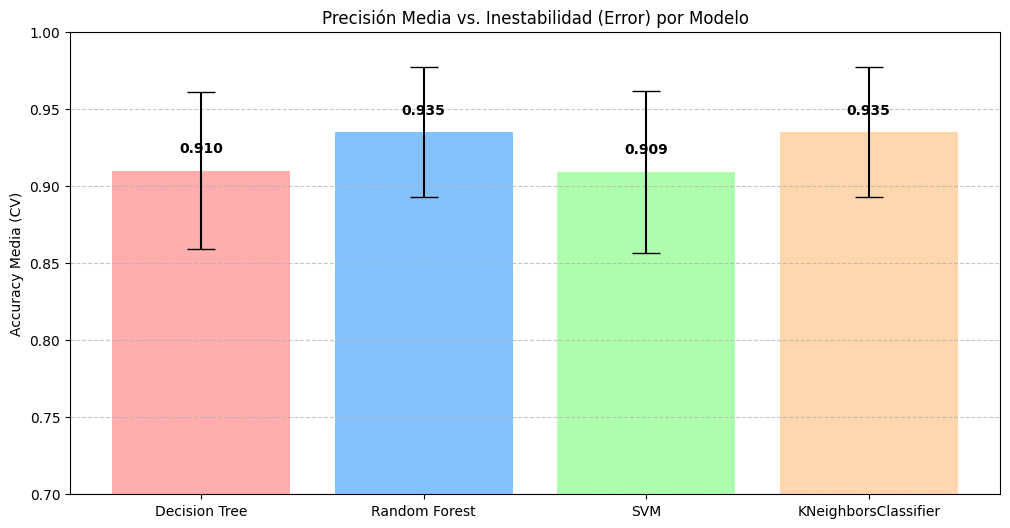

INTERPRETACIÓN:
- Cuanto más alta la barra, mejor es el modelo en promedio.
- Cuanto más larga la línea negra (error), más inestable es el modelo.
- Verás que Decision Tree y SVM tienen la barra más baja, por ello nos quedamos con KNN o Random Forest.


In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Calculamos la media y desviación estándar de los resultados de CV
means = [np.mean(results_cv[name]) for name in best_models.keys()]
stds = [np.std(results_cv[name]) for name in best_models.keys()]
names = list(best_models.keys())

plt.figure(figsize=(12, 6))

# Gráfico de barras con barras de error
bars = plt.bar(names, means, yerr=stds, capsize=10, color=['#ff9999','#66b3ff','#99ff99','#ffcc99'], alpha=0.8)

plt.title('Precisión Media vs. Inestabilidad (Error) por Modelo')
plt.ylabel('Accuracy Media (CV)')
plt.ylim(0.7, 1.0) # Zoom en la zona relevante

# Añadir etiquetas de valor
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("INTERPRETACIÓN:")
print("- Cuanto más alta la barra, mejor es el modelo en promedio.")
print("- Cuanto más larga la línea negra (error), más inestable es el modelo.")
print("- Verás que Decision Tree y SVM tienen la barra más baja, por ello nos quedamos con KNN o Random Forest.")

### 10. Duelo Final: KNN vs. Random Forest
En esta sección comparamos las métricas de rendimiento y los candidatos sugeridos por los dos modelos finalistas.

In [63]:
from sklearn.metrics import classification_report

# 1. Comparativa de Métricas
print("--- REPORTE DE CLASIFICACIÓN: KNN ---")
# Usamos el modelo optimizado por GridSearchCV
knn_best = best_models['KNeighborsClassifier']
y_pred_knn = knn_best.predict(X_test)
print(classification_report(y_test, y_pred_knn))

print("\n--- REPORTE DE CLASIFICACIÓN: RANDOM FOREST ---")
rf_best = best_models['Random Forest']
y_pred_rf = rf_best.predict(X_test)
print(classification_report(y_test, y_pred_rf))

# 2. Comparativa de Candidatos
# Extraemos los 10 mejores de KNN (ya calculados)
# Y los predichos por el Random Forest optimizado
all_predictions_rf_best = rf_best.predict(X_train_dt_full)
similar_indices_rf_best = X_train_dt_full.index[all_predictions_rf_best == 1]

df_rf_final = df_porteros.loc[similar_indices_rf_best].copy()
df_rf_final['distance'] = df_scaled.loc[similar_indices_rf_best, 'distance_to_courtois']
df_rf_final = df_rf_final.sort_values('distance').head(10)

print("\n--- COMPARATIVA DE CANDIDATOS ---")
comparativa_final = pd.DataFrame({
    'Top KNN': df_knn_similar_goalkeepers['Player'].values[:10],
    'Distancia KNN': df_knn_similar_goalkeepers['distance_to_courtois'].values[:10],
    'Top Random Forest': df_rf_final['Player'].values[:10],
    'Distancia RF': df_rf_final['distance'].values[:10]
})

display(comparativa_final)

--- REPORTE DE CLASIFICACIÓN: KNN ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.75      0.86         4

    accuracy                           0.94        16
   macro avg       0.96      0.88      0.91        16
weighted avg       0.94      0.94      0.93        16


--- REPORTE DE CLASIFICACIÓN: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.50      0.67         4

    accuracy                           0.88        16
   macro avg       0.93      0.75      0.79        16
weighted avg       0.89      0.88      0.86        16


--- COMPARATIVA DE CANDIDATOS ---


,Top KNN,Distancia KNN,Top Random Forest,Distancia RF
0,M. Di Gregorio,0.978220,M. Di Gregorio,0.978220
1,L. Horníček,0.991690,L. Horníček,0.991690
2,G. Donnarumma,1.058070,G. Donnarumma,1.058070
3,G. Kobel,1.314914,G. Kobel,1.314914
4,B. Özer,1.326062,B. Özer,1.326062
5,R. Risser,1.386913,R. Risser,1.386913
6,V. Milinković-Savić,1.545877,V. Milinković-Savić,1.545877
7,Luíz Júnior,1.812814,D. Greif,1.962133
8,D. Greif,1.962133,Gabriel Batista,1.986233
9,Gabriel Batista,1.986233,Diogo Costa,1.992436


# 11. ¿Cuál elegir?

* **KNN**: Es el más intuitivo (similitud directa por distancia), ideal si buscamos un 'clon' estadístico, aunque no explica la importancia de cada variable.
* **Random Forest**: Es el más robusto contra valores extraños en los datos (ruido), ya que promedia múltiples árboles para dar un veredicto.

**Veredicto final:** Los dos modelos discrepan en un solo jugador, Diogo Costa o Luiz Junior. Simplemente incluiremos a ambos jugadores en nuestra lista de pretendientes de donde escogeremos uno, ahora teniendo en cuenta criterios de edad, termino del contrato, salario y precio de mercado.